In [1]:
from dataclasses import asdict
from itertools import combinations
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd

import scarf
import scarf.plotting as splt
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts = str(Path(analysis_directory.name) / "counts.zarr")
repack_store(
    f"{dataset}/data.zarr",
    repacked_counts,
    nthreads=2,
)
ds = scarf.mount_datastore(
    repacked_counts,
    at=str(Path(analysis_directory.name) / "clustering_analysis.zarr"),
    default_assay="RNA",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
hvg_ref = ds.mark_hvgs(
    min_cells=20,
    top_n=500,
    show_plot=False,
)
ds.run_normalization(features=hvg_ref)
pca = ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
)

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

Repacking RNA/counts: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

...

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 150 / 150 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='2952be2c8e2d...')

In [2]:
leiden_candidates = {
    0.3: "leiden_r03",
    0.5: "leiden_r05",
    0.8: "leiden_r08",
}
for resolution, label in leiden_candidates.items():
    ds.run_leiden_clustering(
        resolution=resolution,
        label=label,
    )
chosen_key = "RNA_leiden_r05"

In [3]:
cluster_sizes = pd.DataFrame(
    {
        label: pd.Series(
            ds.cells.fetch(f"RNA_{label}", key="I")
        ).value_counts()
        for label in leiden_candidates.values()
    }
).fillna(0).astype(int)
cluster_sizes

,leiden_r03,leiden_r05,leiden_r08
1,722,694,354
2,237,28,368
3,1264,237,237
4,683,1004,708
5,285,317,553
6,317,539,462
7,142,142,287
8,263,263,356
9,15,378,144
10,12,311,151


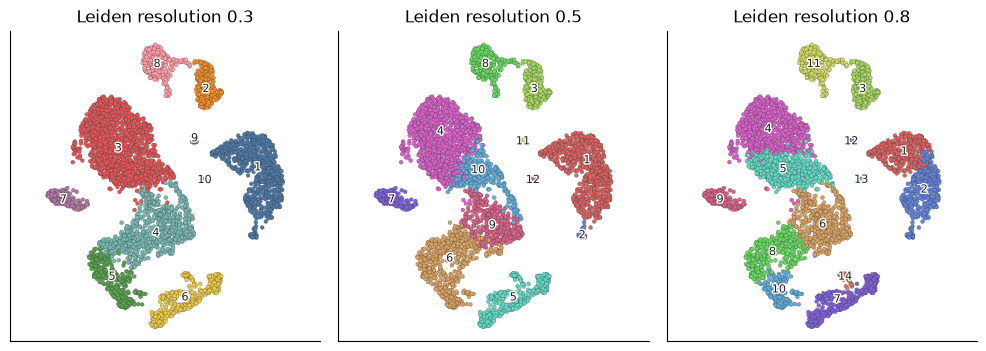

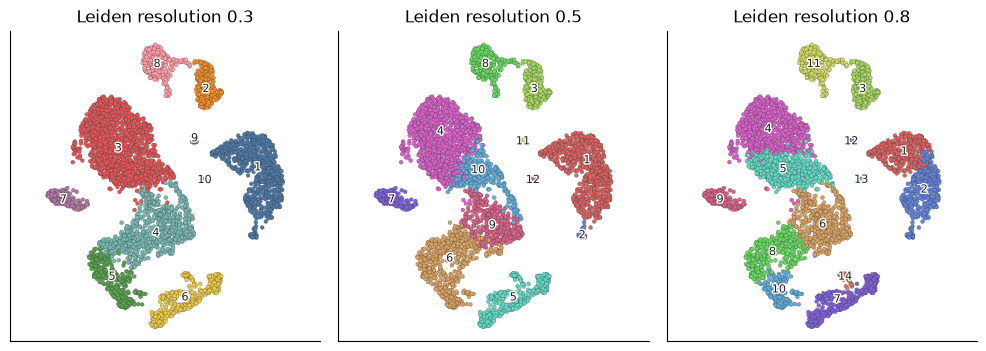

In [4]:
leiden_comparison = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=[f"RNA_{label}" for label in leiden_candidates.values()],
    n_columns=3,
    legend_loc="on_data",
    show_titles=False,
    show=False,
)
for axis, resolution in zip(
    leiden_comparison.axes.values(), leiden_candidates, strict=True
):
    axis.set_title(f"Leiden resolution {resolution}")
leiden_comparison.figure

In [5]:
chosen_sizes = (
    pd.Series(ds.cells.fetch(chosen_key, key="I"))
    .value_counts()
    .sort_values()
)
chosen_sizes

12      12
11      15
2       28
7      142
3      237
8      263
10     311
5      317
9      378
6      539
1      694
4     1004
Name: count, dtype: int64

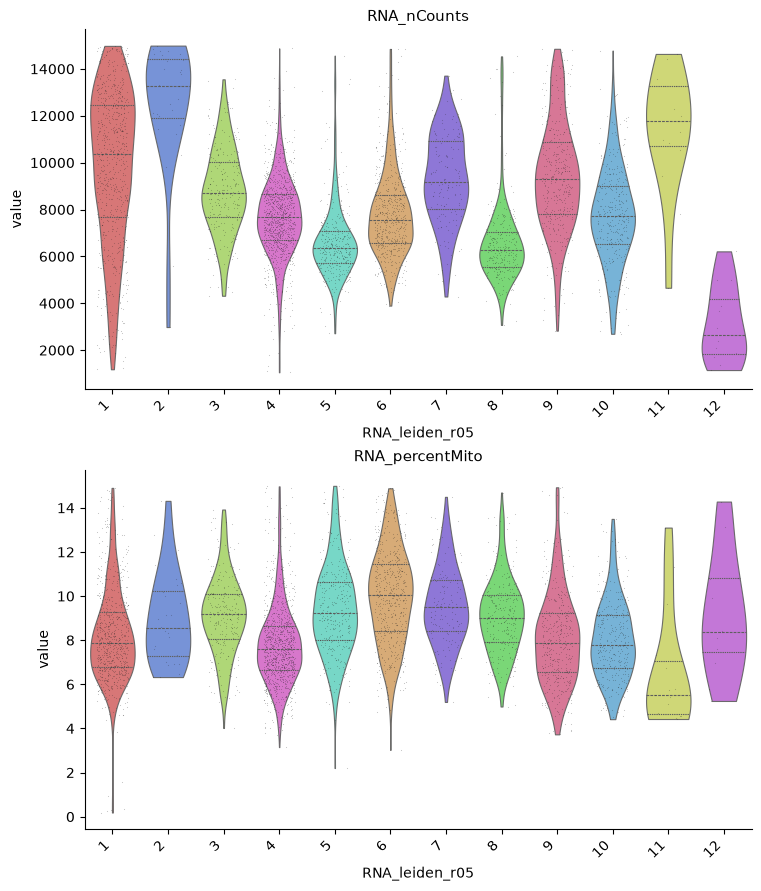

In [6]:
ds.plots.distribution(
    keys=["RNA_nCounts", "RNA_percentMito"],
    group_by=chosen_key,
    kind="violin",
)

In [7]:
agreement_rows = []
for first, second in combinations(leiden_candidates.values(), 2):
    columns = [f"RNA_{first}", f"RNA_{second}"]
    agreement_rows.append(
        {
            "comparison": f"{first} vs {second}",
            "ARI": ds.metric_label_concordance(
                columns,
                metric="ari",
            ),
            "NMI": ds.metric_label_concordance(
                columns,
                metric="nmi",
            ),
        }
    )
pd.DataFrame(agreement_rows)

,comparison,ARI,NMI
0,leiden_r03 vs leiden_r05,0.770245,0.878099
1,leiden_r03 vs leiden_r08,0.647471,0.852723
2,leiden_r05 vs leiden_r08,0.674633,0.847042


In [8]:
silhouette_rows = []
for label in leiden_candidates.values():
    scores = ds.metric_graph_silhouette(res_label=label)
    silhouette_rows.append(
        {
            "partition": label,
            "mean graph silhouette": float(np.nanmean(scores)),
            "minimum graph silhouette": float(np.nanmin(scores)),
        }
    )
pd.DataFrame(silhouette_rows)

Calculating silhouette scores: 10 / 10 complete

Calculating silhouette scores: 12 / 12 complete

Calculating silhouette scores: 14 / 14 complete

,partition,mean graph silhouette,minimum graph silhouette
0,leiden_r03,0.470875,0.221162
1,leiden_r05,0.438659,0.057414
2,leiden_r08,0.338589,-0.130037


In [9]:
graph_scores = ds.metric_graph_silhouette(res_label="leiden_r05")
clusters_all = ds.cells.fetch_all(chosen_key)
active_mask = ds.cells.fetch_all("I").astype(bool)
active_labels = pd.Series(clusters_all[active_mask])
categories = pd.Categorical(active_labels).categories
per_cluster_silhouette = pd.DataFrame(
    {
        "cluster": list(categories),
        "graph_silhouette": graph_scores,
        "n_cells": active_labels.value_counts()
        .reindex(categories)
        .to_numpy(),
    }
)
per_cluster_silhouette

Calculating silhouette scores: 12 / 12 complete

,cluster,graph_silhouette,n_cells
0,1,0.570217,694
1,2,0.565806,28
2,3,0.551815,237
3,4,0.334875,1004
4,5,0.393373,317
5,6,0.057414,539
6,7,0.427800,142
7,8,0.221162,263
8,9,0.491795,378
9,10,0.207806,311


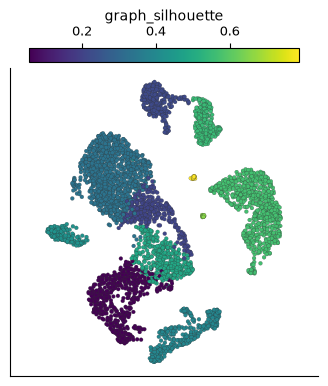

In [10]:
score_map = dict(zip(categories, graph_scores, strict=True))
mapped_silhouette = np.full(len(clusters_all), np.nan, dtype=float)
mapped_silhouette[active_mask] = (
    active_labels.map(score_map).to_numpy(dtype=float)
)
ds.cells.insert(
    "graph_silhouette",
    mapped_silhouette,
    overwrite=True,
)
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="graph_silhouette",
)

In [11]:
separability = ds.metric_cluster_separability(
    pca,
    cluster_columns=[
        f"RNA_{label}" for label in leiden_candidates.values()
    ],
)
separability.clustering_scores

,clustering,n_sampled_cells,n_clusters,macro_f1_mean,macro_f1_standard_error,weighted_f1_mean,silhouette_score,status,status_reason
0,RNA_leiden_r03,3940,10,0.961605,0.005768,0.972438,0.381827,scored,None
1,RNA_leiden_r05,3940,12,0.941547,0.008044,0.962451,0.313879,scored,None
2,RNA_leiden_r08,3940,14,0.940879,0.006719,0.936012,0.245537,scored,None


In [12]:
separability.cluster_scores.query(
    "clustering == @chosen_key"
).sort_values("f1_score")

,clustering,cluster_label,n_sampled_cells,f1_score
21,RNA_leiden_r05,12,12,0.733333
18,RNA_leiden_r05,10,311,0.884244
17,RNA_leiden_r05,9,378,0.922252
20,RNA_leiden_r05,11,15,0.937500
15,RNA_leiden_r05,7,142,0.952381
12,RNA_leiden_r05,4,1004,0.959920
14,RNA_leiden_r05,6,539,0.962825
19,RNA_leiden_r05,2,28,0.965517
13,RNA_leiden_r05,5,317,0.989011
11,RNA_leiden_r05,3,237,0.989474


In [13]:
separability.confusion.query("clustering == @chosen_key")

,clustering,true_cluster,predicted_cluster,n_cells,fraction_of_true_cluster
100,RNA_leiden_r05,1,1,692,0.997118
101,RNA_leiden_r05,1,3,0,0.000000
102,RNA_leiden_r05,1,4,0,0.000000
103,RNA_leiden_r05,1,5,0,0.000000
104,RNA_leiden_r05,1,6,0,0.000000
...,...,...,...,...,...
239,RNA_leiden_r05,12,9,0,0.000000
240,RNA_leiden_r05,12,10,0,0.000000
241,RNA_leiden_r05,12,2,0,0.000000
242,RNA_leiden_r05,12,11,0,0.000000


In [14]:
ds.calc_membership_strength(chosen_key)
membership_key = "RNA_I_cluster_membership_strength"

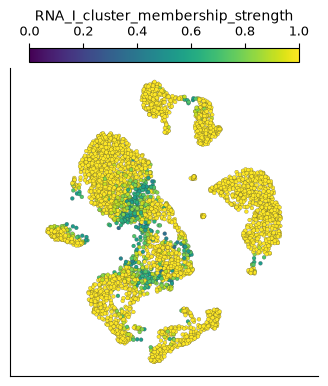

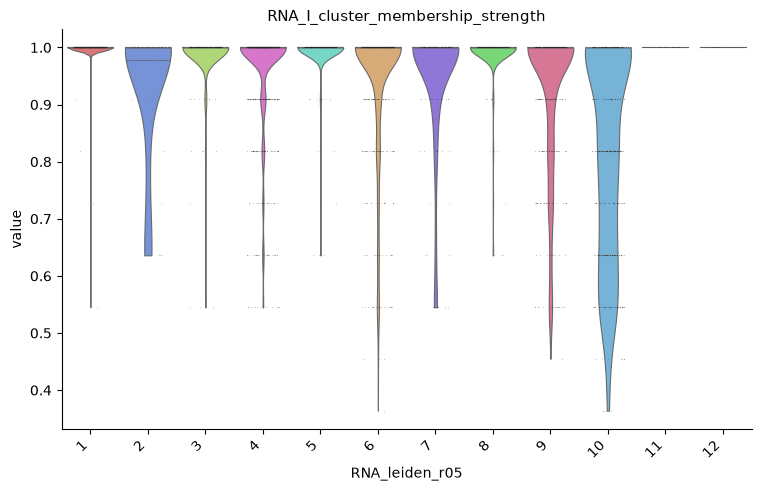

In [15]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=membership_key,
)
ds.plots.distribution(
    keys=membership_key,
    group_by=chosen_key,
    kind="violin",
)

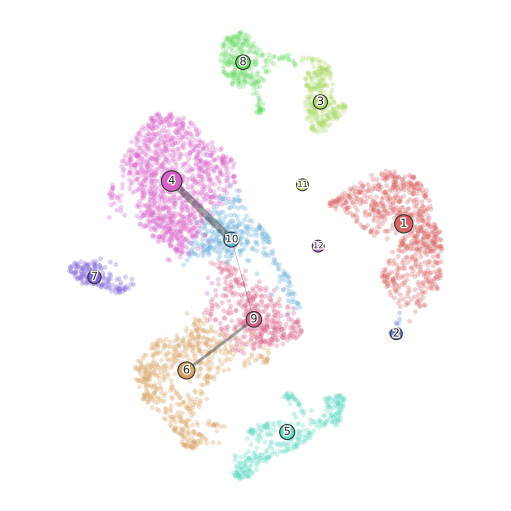

In [16]:
ds.plots.cluster_connectivity(
    group_by=chosen_key,
    layout_key="RNA_UMAP",
    from_assay="RNA",
    show_cells=True,
)

In [17]:
paris_auto = ds.run_paris_clustering(
    n_clusters="auto",
    label="paris_auto",
)
pd.DataFrame(
    [asdict(item) for item in paris_auto.diagnostics]
)[
    [
        "label",
        "size",
        "persistence",
        "decision_margin",
        "forced",
    ]
]

,label,size,persistence,decision_margin,forced
0,1,337,79.705419,0.065040,False
1,2,385,89.092184,0.055471,False
2,3,257,132.482178,0.418605,False
3,4,1269,315.001767,0.067197,False
4,5,317,147.956538,0.164591,False
5,6,558,77.990342,NaN,False
6,7,137,97.023762,0.602801,False
7,8,243,100.905112,0.219834,False
8,9,410,128.162219,0.131857,False
9,10,15,NaN,NaN,True


In [18]:
paris_fixed = ds.run_paris_clustering(
    n_clusters=paris_auto.n_clusters,
    label="paris_fixed",
)
ds.metric_label_concordance(
    [paris_auto.label_key, paris_fixed.label_key],
    metric="ari",
)

0.7311570727308538

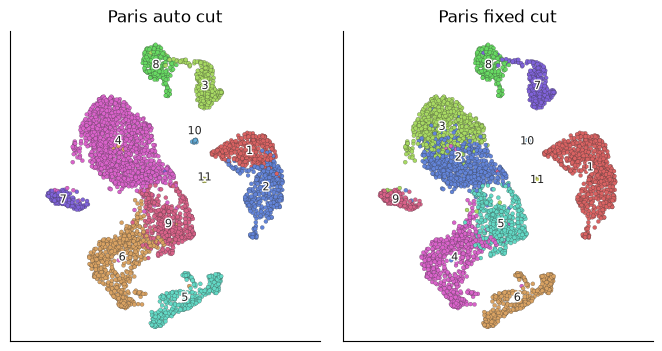

In [19]:
paris_comparison = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=[paris_auto.label_key, paris_fixed.label_key],
    n_columns=2,
    legend_loc="on_data",
    show_titles=False,
    show=False,
)
for axis, title in zip(
    paris_comparison.axes.values(),
    ["Paris auto cut", "Paris fixed cut"],
    strict=True,
):
    axis.set_title(title)
paris_comparison.figure

Constructing graph from dendrogram: 3939 / 3939 complete

Identifying the top node for cluster: 1 / 1 complete

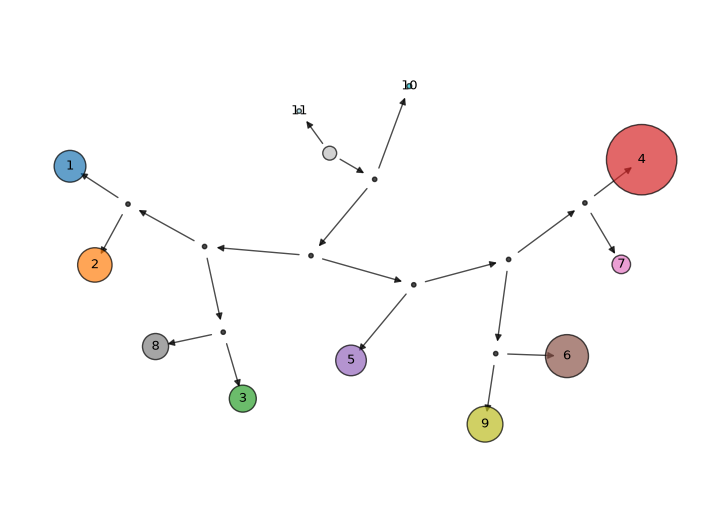

In [20]:
ds.plots.cluster_tree(
    cluster_key=paris_auto.label_key,
    width=1.7,
    fontsize=9,
    figsize=(7, 5),
)

ARI: 0.7362398928924959


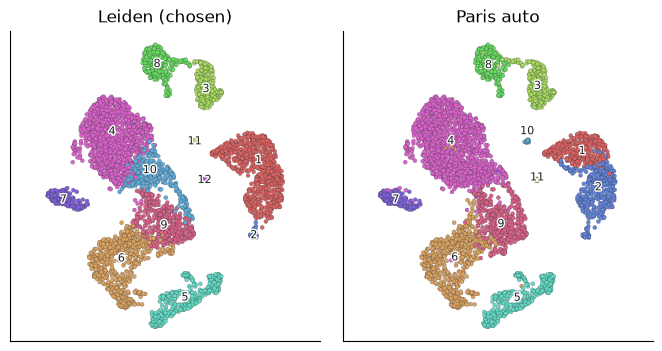

In [21]:
leiden_paris = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=[chosen_key, paris_auto.label_key],
    n_columns=2,
    legend_loc="on_data",
    show_titles=False,
    show=False,
)
for axis, title in zip(
    leiden_paris.axes.values(),
    ["Leiden (chosen)", "Paris auto"],
    strict=True,
):
    axis.set_title(title)
print(
    "ARI:",
    ds.metric_label_concordance(
        [chosen_key, paris_auto.label_key],
        metric="ari",
    ),
)
leiden_paris.figure

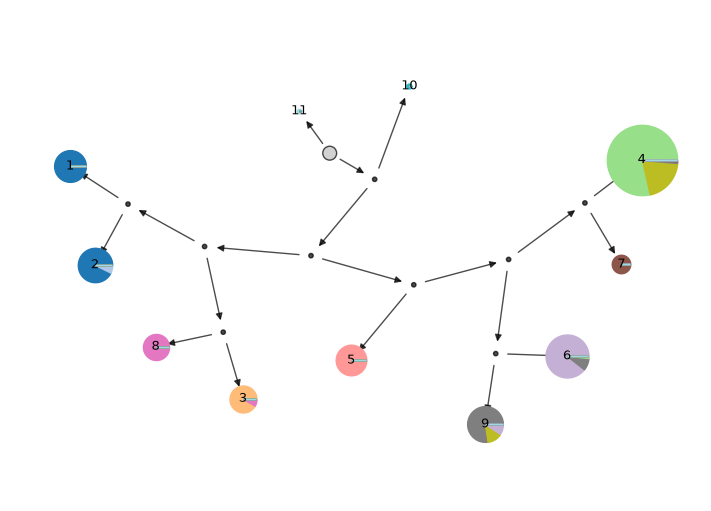

In [22]:
ds.plots.cluster_tree(
    cluster_key=paris_auto.label_key,
    fill_by_value=chosen_key,
    width=1.7,
    fontsize=9,
    figsize=(7, 5),
)

In [23]:
all_features = ds.resolve_features("RNA", "all_features")
ds.run_marker_search(group_key=chosen_key, features=all_features)
largest_group = chosen_sizes.index[-1]
smallest_group = chosen_sizes.index[0]
markers = ds.get_markers(
    group_key=chosen_key,
    group_id=largest_group,
)
print(f"Largest group: {largest_group} (n={int(chosen_sizes.loc[largest_group])})")
markers[
    [
        "feature_name",
        "score",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(10)

Finding markers: 2 / 2 complete

Largest group: 4 (n=1004)


,feature_name,score,auc,p_value,p_value_adjusted
0,ADTRP,0.41057,0.60208,2.122675e-83,3.727239e-81
1,FHIT,0.34388,0.75649,1.297768e-216,1.554448e-213
2,TSHZ2,0.31510,0.62291,4.188060e-84,7.471232e-82
3,CMTM8,0.31237,0.61065,2.354141e-65,2.892058e-63
4,EPHX2,0.31103,0.64836,3.218353e-101,7.709795e-99
5,LRRN3,0.30605,0.72201,1.099399e-191,9.703067e-189
6,CHRM3-AS2,0.30605,0.64164,3.369847e-97,7.435389e-95
7,NOG,0.30290,0.61092,1.214071e-91,2.482776e-89
8,MAN1C1,0.30181,0.60891,1.353549e-59,1.363223e-57
9,GSTM3,0.30174,0.60525,3.537595e-62,3.994743e-60


In [24]:
small_markers = ds.get_markers(
    group_key=chosen_key,
    group_id=smallest_group,
)
print(
    f"Smallest group: {smallest_group} "
    f"(n={int(chosen_sizes.loc[smallest_group])})"
)
small_markers[
    [
        "feature_name",
        "score",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(10)

Smallest group: 12 (n=12)


,feature_name,score,auc,p_value,p_value_adjusted
0,F13A1,0.81787,0.99998,2.737010e-45,4.477748e-43
1,ACRBP,0.80562,0.95774,2.061862e-132,6.286431e-130
2,PTGS1,0.79792,0.99998,2.044860e-73,5.042684e-71
3,PRKAR2B,0.79786,1.00000,2.000594e-184,1.016605e-181
4,AP003068.2,0.79489,0.95765,1.075183e-118,3.004959e-116
5,TST,0.79442,0.95476,2.582438e-41,4.124276e-39
6,CD9,0.79128,0.99992,8.068113e-78,2.049912e-75
7,HIST1H3H,0.78964,0.95730,1.836591e-99,5.007773e-97
8,CLU,0.78698,1.00000,2.078877e-194,1.106689e-191
9,HIST1H2BJ,0.78389,0.87170,5.732431e-54,9.808892e-52


Aggregating marker values per group: 1 / 1 complete

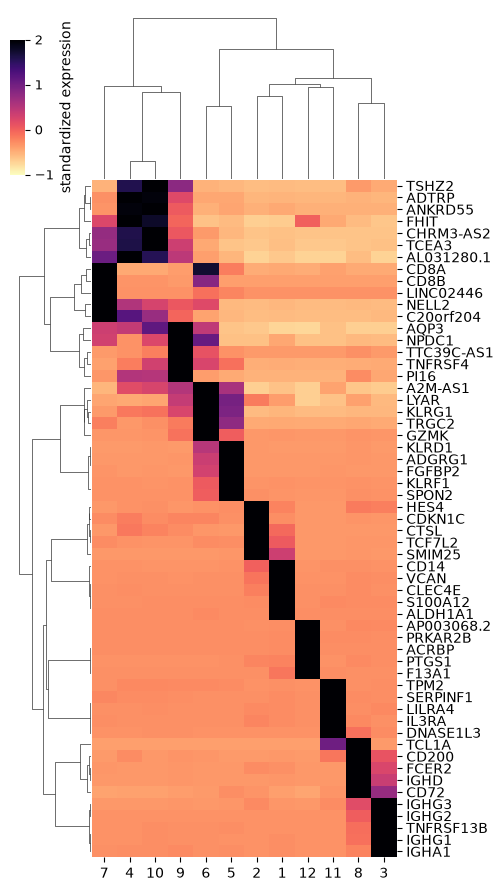

In [25]:
ds.plots.marker_heatmap(
    group_key=chosen_key,
    topn=5,
    figsize=(5, 9),
)

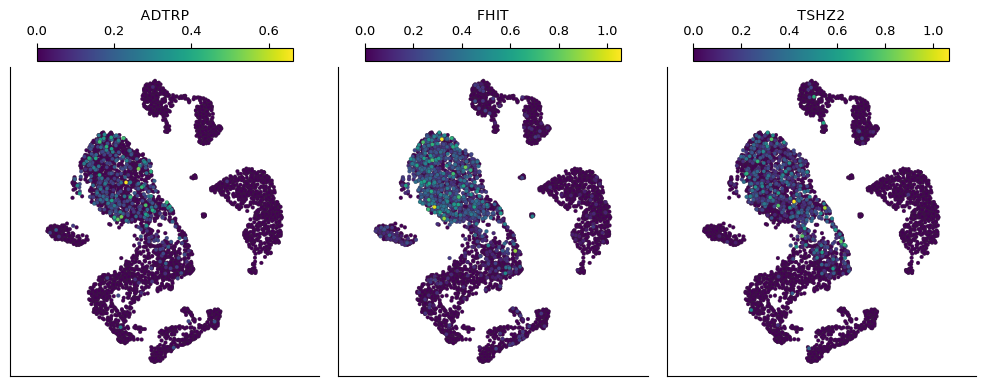

In [26]:
top_genes = markers["feature_name"].astype(str).head(3).tolist()
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=top_genes,
    n_columns=3,
    sort_values=True,
)

Focus cluster: 4
Focus cells: 1004


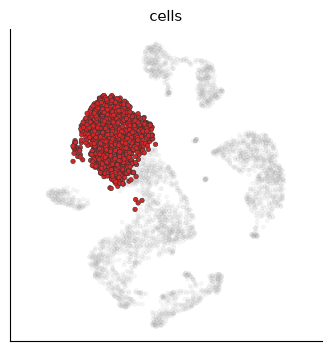

In [27]:
clusters = ds.cells.fetch_all(chosen_key)
active = ds.cells.fetch_all("I").astype(bool)
focus = pd.Series(clusters[active]).value_counts().index[0]
ds.cells.insert(
    "focus_cells",
    active & (clusters == focus),
    overwrite=True,
)
print(f"Focus cluster: {focus}")
print(f"Focus cells: {int(ds.cells.fetch_all('focus_cells').sum())}")
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=None,
    default_color="#bdbdbd",
    point_alpha=0.4,
    highlight=splt.Highlight(
        by="focus_cells",
        groups=(True,),
        color="#d62728",
        dim_alpha=0.12,
        size_multiplier=1.35,
        halo_width=0.4,
    ),
)

In [28]:
focus_features = ds.mark_hvgs(
    cell_key="focus_cells",
    min_cells=10,
    top_n=500,
    show_plot=False,
)
ds.run_normalization(
    cell_key="focus_cells",
    features=focus_features,
)
ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_umap(
    cell_key="focus_cells",
    n_epochs=100,
    spread=5,
    min_dist=1,
    parallel=True,
    label="UMAP",
)
ds.run_leiden_clustering(
    cell_key="focus_cells",
    resolution=0.4,
    label="leiden_cluster",
)
pd.Series(
    ds.cells.fetch("RNA_focus_cells_leiden_cluster", key="focus_cells")
).value_counts()

Calculating feature statistics: 30 / 30 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 100 / 100 complete

2    519
1    485
Name: count, dtype: int64

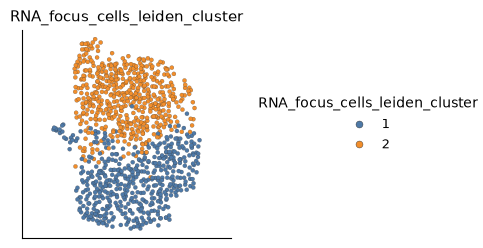

In [29]:
ds.plots.embedding(
    layout_key="RNA_focus_cells_UMAP",
    color_by="RNA_focus_cells_leiden_cluster",
    cell_key="focus_cells",
)